### Import

In [30]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.preprocessing import  OrdinalEncoder
from sklearn.preprocessing import  OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, average_precision_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Data Preprocess

In [2]:
train_df = pd.read_csv("Data/train.csv")
test_df = pd.read_csv("Data/test.csv")

In [3]:
# 결측치 비율 3% 넘는 열 삭제(train)
threshold = 0.03  
missing_ratio = train_df.isnull().sum() / len(train_df)
columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
train_df_cleaned = train_df.drop(columns=columns_to_drop)
columns_to_drop

['임신 시도 또는 마지막 임신 경과 연수',
 '착상 전 유전 검사 사용 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자 혼합 경과일',
 '배아 이식 경과일',
 '배아 해동 경과일']

In [4]:
# 결측치 비율 3% 넘는 열 삭제(test)
missing_ratio = test_df.isnull().sum() / len(test_df)
columns_to_drop = missing_ratio[missing_ratio > threshold].index.tolist()
test_df_cleaned = test_df.drop(columns=columns_to_drop)
columns_to_drop

['임신 시도 또는 마지막 임신 경과 연수',
 '착상 전 유전 검사 사용 여부',
 'PGD 시술 여부',
 'PGS 시술 여부',
 '난자 채취 경과일',
 '난자 해동 경과일',
 '난자 혼합 경과일',
 '배아 이식 경과일',
 '배아 해동 경과일']

In [7]:
missing_values = train_df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

해동된 배아 수            6291
단일 배아 이식 여부         6291
기증 배아 사용 여부         6291
신선 배아 사용 여부         6291
동결 배아 사용 여부         6291
기증자 정자와 혼합된 난자 수    6291
파트너 정자와 혼합된 난자 수    6291
혼합된 난자 수            6291
저장된 신선 난자 수         6291
수집된 신선 난자 수         6291
해동 난자 수             6291
대리모 여부              6291
미세주입 후 저장된 배아 수     6291
저장된 배아 수            6291
미세주입 배아 이식 수        6291
이식된 배아 수            6291
미세주입에서 생성된 배아 수     6291
미세주입된 난자 수          6291
총 생성 배아 수           6291
배아 생성 주요 이유         6291
착상 전 유전 진단 사용 여부    6291
특정 시술 유형               2
dtype: int64

In [16]:
missing_values = test_df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
missing_values

단일 배아 이식 여부         2176
해동 난자 수             2176
기증 배아 사용 여부         2176
신선 배아 사용 여부         2176
동결 배아 사용 여부         2176
기증자 정자와 혼합된 난자 수    2176
파트너 정자와 혼합된 난자 수    2176
혼합된 난자 수            2176
저장된 신선 난자 수         2176
수집된 신선 난자 수         2176
해동된 배아 수            2176
착상 전 유전 진단 사용 여부    2176
미세주입 후 저장된 배아 수     2176
저장된 배아 수            2176
미세주입 배아 이식 수        2176
이식된 배아 수            2176
미세주입에서 생성된 배아 수     2176
미세주입된 난자 수          2176
총 생성 배아 수           2176
배아 생성 주요 이유         2176
대리모 여부              2176
dtype: int64

In [56]:
di_count = train_df[train_df['시술 유형'] == 'DI'].shape[0]
di_count

6291

In [67]:
di_count = test_df[test_df['시술 유형'] == 'DI'].shape[0]
di_count

C:\Users\jwChoi\AppData\Local\Temp\ipykernel_9648\1598425158.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  di_count = test_df[train_df['시술 유형'] == 'DI'].shape[0]


2256

In [17]:
# 결측치 있는 특성 가져오기
categorical_cols = test_df_cleaned.select_dtypes(include=['object']).columns
numerical_cols = train_df_cleaned.select_dtypes(include=['float64', 'int64']).columns

missing_columns = missing_values.index.tolist()
missing_num = [col for col in missing_columns if col in numerical_cols]
missing_cat = [col for col in missing_columns if col in categorical_cols]
print('num:', missing_num)
print('cat:', missing_cat)

['해동 난자 수', '기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동된 배아 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수', '총 생성 배아 수']
['단일 배아 이식 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '착상 전 유전 진단 사용 여부', '배아 생성 주요 이유', '대리모 여부']


#### numerical 결측치 처리

In [11]:
# 알 수 없는 열은 -1(train)
missing_num_what = ['기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '총 생성 배아 수']
train_df_cleaned[missing_num_what] = train_df_cleaned[missing_num_what].fillna(-1)
# DI이므로 무조건 0인 열(train)
missing_num_zero = ['해동된 배아 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동 난자 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수']
train_df_cleaned[missing_num_zero] = train_df_cleaned[missing_num_zero].fillna(0)

In [18]:
# 알 수 없는 열은 -1(test)
missing_num_what = ['기증자 정자와 혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '혼합된 난자 수', '총 생성 배아 수']
test_df_cleaned[missing_num_what] = test_df_cleaned[missing_num_what].fillna(-1)
# DI이므로 무조건 0인 열(test)
missing_num_zero = ['해동된 배아 수', '저장된 신선 난자 수', '수집된 신선 난자 수', '해동 난자 수', '미세주입 후 저장된 배아 수', '저장된 배아 수', '미세주입 배아 이식 수', '이식된 배아 수', '미세주입에서 생성된 배아 수', '미세주입된 난자 수']
test_df_cleaned[missing_num_zero] = test_df_cleaned[missing_num_zero].fillna(0)

#### categorical 결측치 처리

In [13]:
# DI는 본인 난자, 0(False)으로 처리(train)
missing_cat_zero = ['단일 배아 이식 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '대리모 여부']
train_df_cleaned[missing_cat_zero] = train_df_cleaned[missing_cat_zero].fillna(0)
# 알 수 없음
train_df_cleaned = train_df_cleaned.drop(columns=['착상 전 유전 진단 사용 여부'])
train_df_cleaned['배아 생성 주요 이유'] = train_df_cleaned['배아 생성 주요 이유'].fillna('관련없음')
train_df_cleaned['특정 시술 유형'] = train_df_cleaned['특정 시술 유형'].fillna('Unknown')

In [20]:
# (test)
missing_cat_zero = ['단일 배아 이식 여부', '기증 배아 사용 여부', '신선 배아 사용 여부', '동결 배아 사용 여부', '대리모 여부']
test_df_cleaned[missing_cat_zero] = test_df_cleaned[missing_cat_zero].fillna(0)

In [21]:
test_df_cleaned = test_df_cleaned.drop(columns=['착상 전 유전 진단 사용 여부'])
test_df_cleaned['배아 생성 주요 이유'] = test_df_cleaned['배아 생성 주요 이유'].fillna('관련없음')

### 결측치 시각화

d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\sit

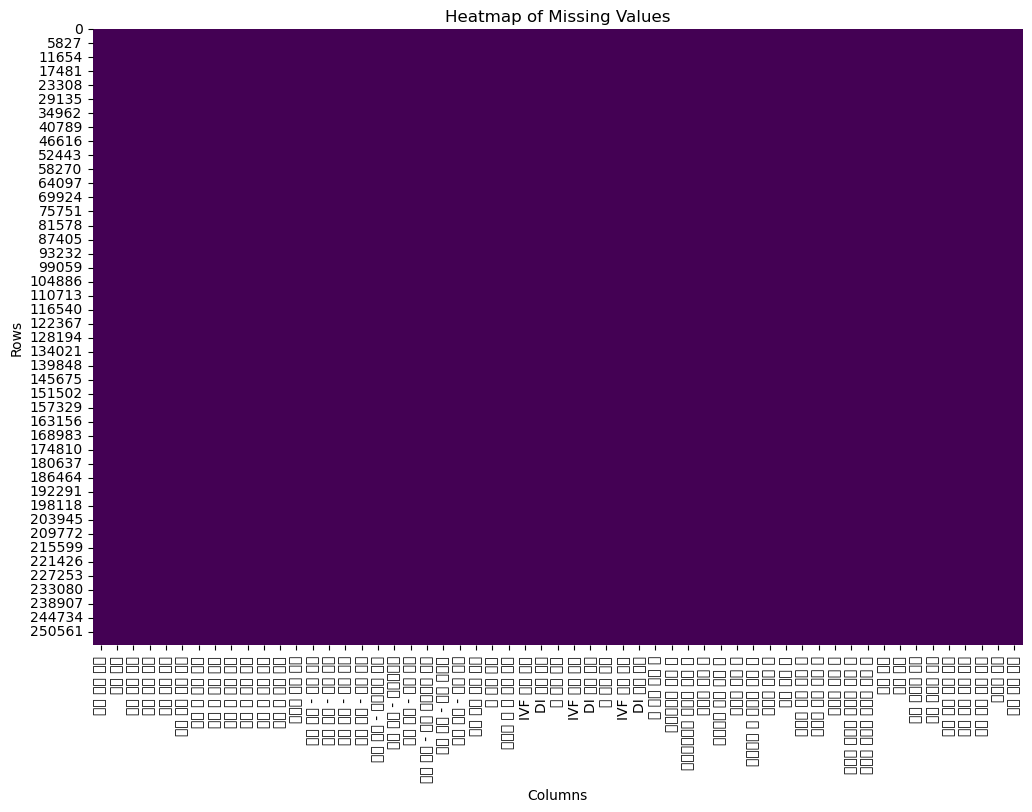

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(train_df_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45817 (\N{HANGUL SYLLABLE DANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
d:\env\envs\aimers\Lib\sit

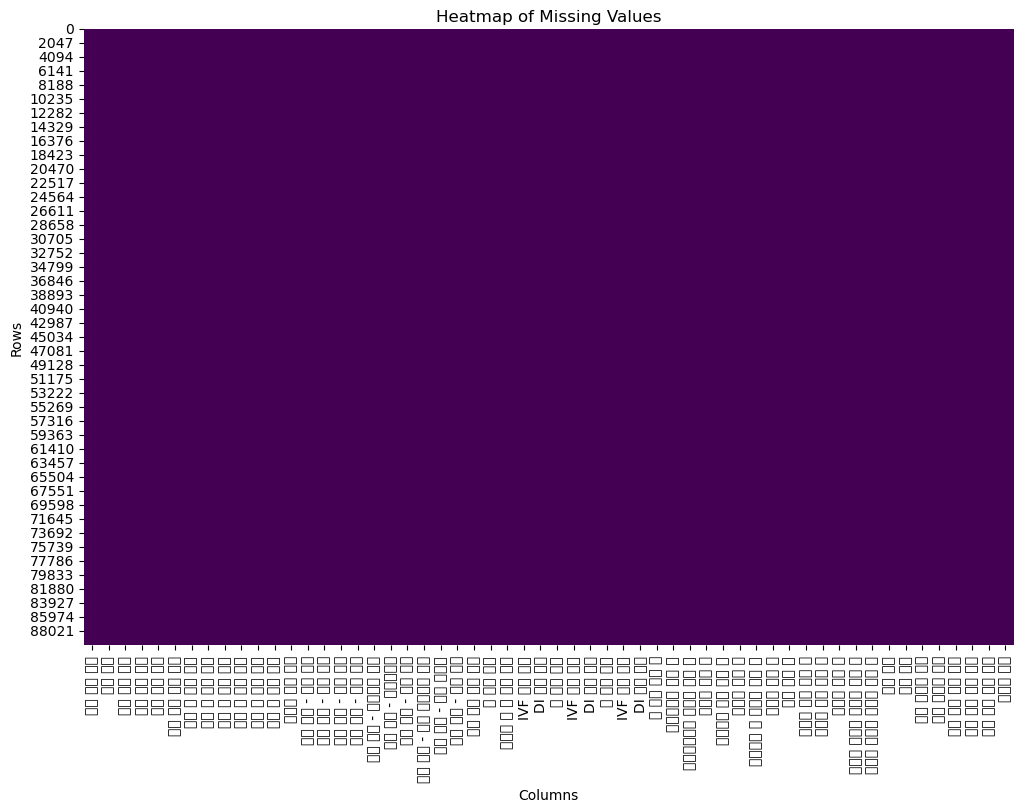

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(test_df_cleaned.isnull(), cbar=False, cmap='viridis')
plt.title('Heatmap of Missing Values')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

### 저장

In [64]:
train_df_cleaned.to_csv('train_cleaned.csv', index=False, encoding='utf-8-sig')

In [23]:
test_df_cleaned.to_csv('test_cleaned.csv', index=False, encoding='utf-8-sig')